# Dataset 6: Mental Health Text Classification — Data Cleaning & Preprocessing
**Model target:** Model 2 — Mental Health Condition Classifier (combined with Dataset 5)
**HuggingFace:** `ourafla/Mental-Health_Text-Classification_Dataset`
**Link:** https://huggingface.co/datasets/ourafla/Mental-Health_Text-Classification_Dataset
**License:** Research and education — freely accessible, no login
**Size:** 48,945 training samples
**Task:** Multi-label MH condition classification: depression, anxiety, stress, burnout, PTSD

---
## 6.1 Why This Dataset Instead of SMHD?

SMHD (Self-Reported Mental Health Diagnoses) requires an institutional email from a recognised university — inaccessible to students. This dataset contains 48,945 labelled samples covering Depression, Anxiety, Suicidal, and Normal classes, derived from three public mental health corpora with a unified 4-class scheme.

**What it provides that Dataset 5 doesn't:**
- Cleaner, more explicit labels (professionally mapped, not keyword-inferred)
- A balanced test split (992 rows, 248 per class) — useful for fair evaluation
- Additional Suicidal class that overlaps with our crisis detection training
- Different text sources = better generalisation when combined with Dataset 5

## 6.2 Label Mapping Strategy
Original labels: `Depression`, `Anxiety`, `Suicidal`, `Normal`
Our target conditions: `depression`, `anxiety`, `stress`, `burnout`, `ptsd`

Mapping: Depression→depression, Anxiety→anxiety, Suicidal→(crisis signal, also depression proxy), Normal→no condition. We use keyword detection for stress/burnout/ptsd since the original dataset doesn't have these labels.

In [1]:
import re, json, hashlib, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
import os; os.makedirs('figures', exist_ok=True)
os.makedirs('data/cleaned', exist_ok=True)

CONDITIONS = ['depression', 'anxiety', 'stress', 'burnout', 'ptsd']

# Label mapping from original 4-class to our conditions
# Suicidal maps to depression (suicidal ideation is a depression symptom)
# and also to crisis flag (used in combination with crisis model)
LABEL_TO_CONDITIONS = {
    'depression':  ['depression'],
    'Depression':  ['depression'],
    'anxiety':     ['anxiety'],
    'Anxiety':     ['anxiety'],
    'suicidal':    ['depression'],   # suicidal ideation → depression proxy
    'Suicidal':    ['depression'],
    'normal':      [],               # no condition
    'Normal':      [],
}

CONDITION_KEYWORDS = {
    'stress':   ['stress','overwhelm','pressure','too much','can\'t cope',
                 'breaking point','deadlines','stretched thin'],
    'burnout':  ['burnout','burnt out','burned out','emotionally drained',
                 'no motivation','hate my job','can\'t function'],
    'ptsd':     ['ptsd','trauma','abuse','flashback','nightmare',
                 'trigger','intrusive thought','hypervigilant'],
}
print('Ready.')

Ready.


In [3]:
# LOAD DATASET
print("Loading ourafla/Mental-Health_Text-Classification_Dataset...")
raw = load_dataset("ourafla/Mental-Health_Text-Classification_Dataset", data_files="mental_heath_unbanlanced.csv")
print(raw)
print(f"\nAvailable splits: {list(raw.keys())}")

# Inspect the first available split
split_name = list(raw.keys())[0]
df = raw[split_name].to_pandas()
print(f"\nUsing split: {split_name}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df.iloc[:, -1].value_counts())  # last column is usually label
print(f"\nSample rows:")
print(df.head(3))

Loading ourafla/Mental-Health_Text-Classification_Dataset...
DatasetDict({
    train: Dataset({
        features: ['Unique_ID', 'text', 'status'],
        num_rows: 49612
    })
})

Available splits: ['train']

Using split: train
Shape: (49612, 3)
Columns: ['Unique_ID', 'text', 'status']

Label distribution:
status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

Sample rows:
   Unique_ID                                               text   status
0        0.0                                         oh my gosh  Anxiety
1        1.0  trouble sleeping, confused mind, restless hear...  Anxiety
2        2.0  All wrong, back off dear, forward doubt. Stay ...  Anxiety


In [4]:
# IDENTIFY TEXT AND LABEL COLUMNS
# Column names vary — auto-detect
text_col  = None
label_col = None

for col in df.columns:
    if df[col].dtype == object:
        avg_len = df[col].dropna().apply(lambda x: len(str(x))).mean()
        if avg_len > 50 and text_col is None:
            text_col = col
        elif avg_len < 30 and label_col is None:
            label_col = col

# Manual fallback
if text_col is None:
    text_col = 'text' if 'text' in df.columns else df.columns[0]
if label_col is None:
    label_col = 'label' if 'label' in df.columns else df.columns[-1]

print(f"Text column  : '{text_col}'")
print(f"Label column : '{label_col}'")
print(f"\nUnique labels: {df[label_col].unique().tolist()}")
print(f"\nSample:")
for _, row in df.head(3).iterrows():
    print(f"  label={row[label_col]!r} | text={str(row[text_col])[:80]}")

Text column  : 'text'
Label column : 'status'

Unique labels: ['Anxiety', 'Normal', 'Depression', 'Suicidal']

Sample:
  label='Anxiety' | text=oh my gosh
  label='Anxiety' | text=trouble sleeping, confused mind, restless heart. All out of tune
  label='Anxiety' | text=All wrong, back off dear, forward doubt. Stay in a restless and restless place


PROBLEMS IN RAW DATA
Null/empty texts  : 0
Under 5 words     : 2708
Over 300 words    : 1017
Exact duplicates  : 667


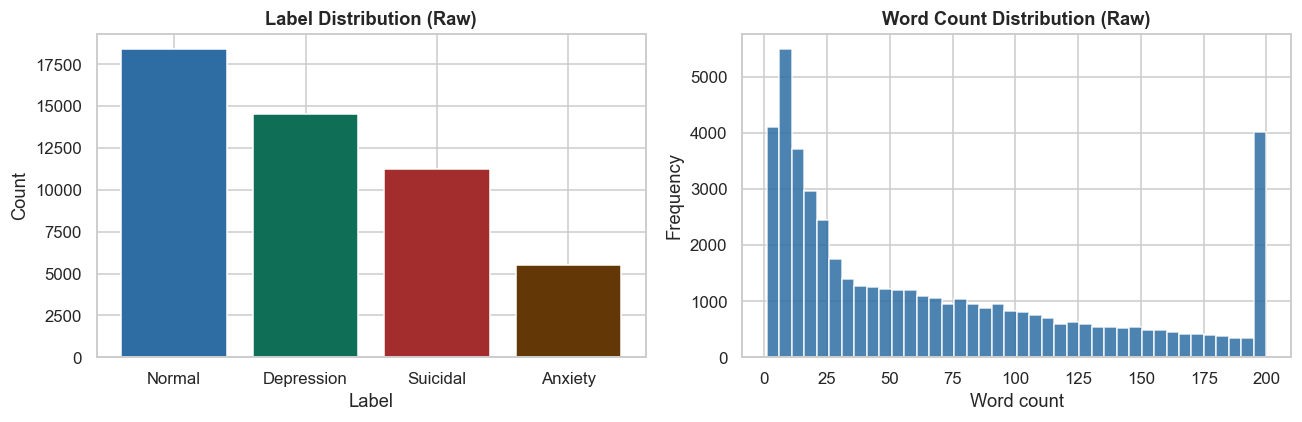

In [5]:
# EDA
df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))

print("PROBLEMS IN RAW DATA")
print("=" * 50)
empty      = df[text_col].isna().sum() + (df[text_col].str.strip()=='').sum()
very_short = (df['word_count'] < 5).sum()
very_long  = (df['word_count'] > 300).sum()
dupes      = df[text_col].duplicated().sum()

print(f"Null/empty texts  : {empty}")
print(f"Under 5 words     : {very_short}")
print(f"Over 300 words    : {very_long}")
print(f"Exact duplicates  : {dupes}")

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts = df[label_col].value_counts()
axes[0].bar(label_counts.index, label_counts.values,
            color=['#2E6DA4','#0F6E56','#A32D2D','#633806'][:len(label_counts)],
            edgecolor='white')
axes[0].set_title('Label Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

df['word_count'].clip(upper=200).hist(bins=40, ax=axes[1],
                                       color='#2E6DA4', edgecolor='white', alpha=0.85)
axes[1].set_title('Word Count Distribution (Raw)', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('figures/06a_ourafla_raw_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# CLEANING AND LABEL MAPPING
RE_URL   = re.compile(r'https?://\S+|www\.\S+')
RE_HTML  = re.compile(r'&amp;|&lt;|&gt;|&quot;')
RE_SPACE = re.compile(r'[ \t]+')

def clean_text(text, min_words=5, max_words=300):
    """Standard cleaning pipeline for this dataset.
    min_words=5: This dataset has cleaner, longer texts than Reddit.
                 5-word minimum is appropriate."""
    if not isinstance(text, str) or not text.strip():
        return None
    text = unicodedata.normalize('NFKC', text)
    text = RE_URL.sub(' ', text)
    text = RE_HTML.sub(' ', text)
    text = RE_SPACE.sub(' ', text).strip()
    words = text.split()
    if len(words) < min_words:
        return None
    return ' '.join(words[:max_words])

def map_to_conditions(label, text):
    """
    Map original label to our 5-condition multi-label format.

    Step 1: Map original label to primary conditions
      (Depression→depression, Anxiety→anxiety, etc.)
    Step 2: Scan text for additional conditions not in original labels
      (stress, burnout, ptsd — not in original 4-class scheme)
    Step 3: Combine both into final condition list

    This enriches the labels beyond the original 4-class scheme.
    """
    label_str = str(label).strip()
    primary = LABEL_TO_CONDITIONS.get(label_str, [])

    # Add keyword-detected conditions for stress/burnout/ptsd
    t = str(text).lower()
    extra = [cond for cond, kws in CONDITION_KEYWORDS.items()
             if any(kw in t for kw in kws)]

    all_conditions = list(set(primary + extra))
    vector = [1 if c in all_conditions else 0 for c in CONDITIONS]
    return all_conditions, vector

# Test
test_cases = [
    ('Depression', 'I have been feeling hopeless and empty for months'),
    ('Anxiety',    'I get panic attacks every morning, too scared to leave'),
    ('Suicidal',   'I have been having thoughts of ending my life'),
    ('Normal',     'Had a great day with friends, feeling good about life'),
    ('Anxiety',    'completely burned out from work stress and anxiety'),
]
print("Label mapping tests:")
for label, text in test_cases:
    conds, vec = map_to_conditions(label, text)
    print(f"  Original: {label:12s} → MindLens: {conds}")

Label mapping tests:
  Original: Depression   → MindLens: ['depression']
  Original: Anxiety      → MindLens: ['anxiety']
  Original: Suicidal     → MindLens: ['depression']
  Original: Normal       → MindLens: []
  Original: Anxiety      → MindLens: ['stress', 'burnout', 'anxiety']


In [7]:
# APPLY CLEANING TO ALL ROWS
rows = []
stats = {'kept':0,'null':0,'short':0,'bad_label':0}
seen_hashes = set()
dupes = 0

for _, row in df.iterrows():
    text  = str(row.get(text_col, ''))
    label = row.get(label_col, '')

    cleaned = clean_text(text)
    if cleaned is None:
        stats['null' if not text.strip() else 'short'] += 1
        continue

    conditions, vector = map_to_conditions(label, cleaned)

    # Deduplicate
    h = hashlib.md5(re.sub(r'\s+','',cleaned.lower()).encode()).hexdigest()
    if h in seen_hashes:
        dupes += 1
        continue
    seen_hashes.add(h)

    rows.append({
        'text': cleaned,
        'original_label': str(label),
        'conditions': conditions,
        'condition_vector': vector,
        'source': 'ourafla_mh_classification',
    })
    stats['kept'] += 1

clean_df = pd.DataFrame(rows)
print(f"Original : {len(df):,}")
print(f"Kept     : {stats['kept']:,} ({stats['kept']/len(df)*100:.1f}%)")
print(f"Short    : {stats['short']:,}")
print(f"Dupes    : {dupes:,}")

# Condition distribution after mapping
print("\nCondition distribution after mapping:")
for cond in CONDITIONS:
    count = sum(1 for r in rows if cond in r['conditions'])
    print(f"  {cond:12s}: {count:,} ({count/len(rows)*100:.1f}%)")

Original : 49,612
Kept     : 46,432 (93.6%)
Short    : 2,691
Dupes    : 489

Condition distribution after mapping:
  depression  : 25,335 (54.6%)
  anxiety     : 5,245 (11.3%)
  stress      : 2,923 (6.3%)
  burnout     : 280 (0.6%)
  ptsd        : 1,974 (4.3%)


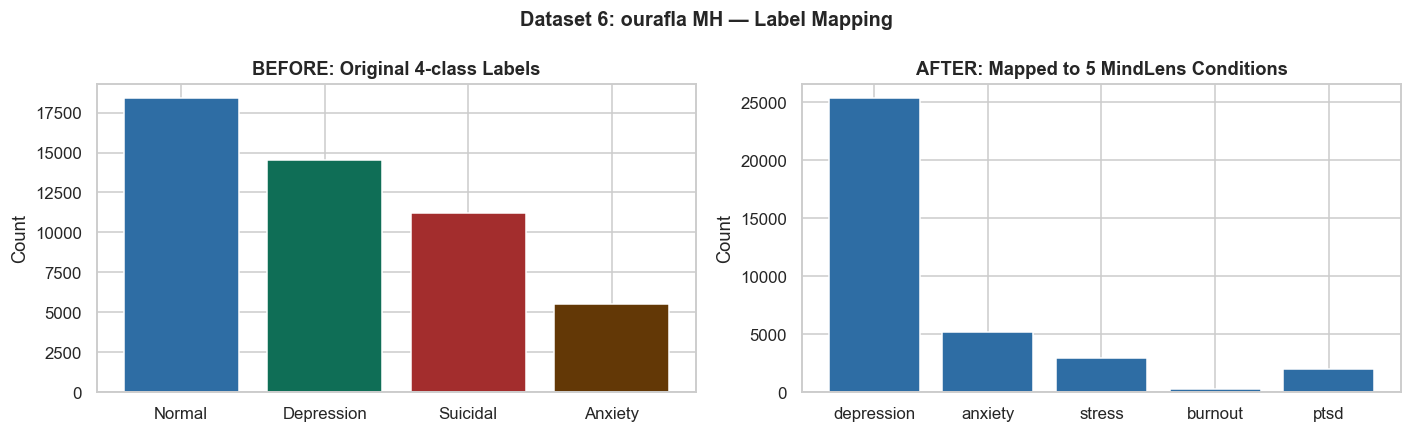

In [8]:
# BEFORE/AFTER VISUALISATION
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before: original 4 labels
orig_counts = df[label_col].value_counts()
axes[0].bar(orig_counts.index, orig_counts.values,
            color=['#2E6DA4','#0F6E56','#A32D2D','#633806'][:len(orig_counts)],
            edgecolor='white')
axes[0].set_title('BEFORE: Original 4-class Labels', fontweight='bold')
axes[0].set_ylabel('Count')

# After: our 5 conditions
cond_counts = {c: sum(1 for r in rows if c in r['conditions']) for c in CONDITIONS}
axes[1].bar(cond_counts.keys(), cond_counts.values(),
            color='#2E6DA4', edgecolor='white')
axes[1].set_title('AFTER: Mapped to 5 MindLens Conditions', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Dataset 6: ourafla MH — Label Mapping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/06b_ourafla_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# SPLIT AND SAVE
n = len(clean_df)
train_df = clean_df.iloc[:int(n*0.8)]
val_df   = clean_df.iloc[int(n*0.8):int(n*0.9)]
test_df  = clean_df.iloc[int(n*0.9):]

ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df,   preserve_index=False),
    'test':       Dataset.from_pandas(test_df,  preserve_index=False),
})
ds.save_to_disk('data/cleaned/ourafla_mh')
ds.push_to_hub('AmiruMallawarachchi/mindlens-ourafla-mh-cleaned')
print(f"Saved. train={len(train_df):,}, val={len(val_df):,}, test={len(test_df):,}")
print("\n✓ Notebook 6 complete.")
print("  Run 00_Master_Summary.ipynb to combine with Dataset 5.")

Saving the dataset (0/1 shards):   0%|          | 0/37145 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4643 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4644 [00:00<?, ? examples/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/38 [00:00<?, ?ba/s]

...

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


Saved. train=37,145, val=4,643, test=4,644

✓ Notebook 6 complete.
  Run 00_Master_Summary.ipynb to combine with Dataset 5.


## 6.8 Preprocessing Summary

| Step | Problem | Fix | Reason |
|------|---------|-----|--------|
| 1 | 4 original labels not matching our 5 | Mapping: Depression→depression, Anxiety→anxiety | Align to MindLens condition schema |
| 2 | Suicidal label | Map to depression (proxy) | Suicidal ideation is a depression symptom in DSM-5 |
| 3 | No stress/burnout/ptsd labels | Keyword scan on text | Enrich beyond original label scheme |
| 4 | Short texts < 5 words | Filter | No classifiable signal |
| 5 | Duplicates | MD5 dedup | Prevent leakage |
| 6 | condition_vector | 5-dim binary | BCEWithLogitsLoss format |

**Why this replaces SMHD:**
SMHD requires institutional email access. This dataset is freely available, has 48,945 clean samples, and — when combined with Dataset 5 (151k Reddit posts) — gives Model 2 over 60,000 total training examples covering all 5 target conditions.